In [2]:
import sqlglot.lineage
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify
from sqlglot.lineage import lineage, GraphHTML
from sqlglot import exp

import logging
import sys
# logging.basicConfig(
#     stream=sys.stdout,
#     level=logging.DEBUG,
#     format='%(name)s - %(levelname)s - %(message)s'
# )


sql1 = """
SELECT
    ranked_customers.customer_id,
    ranked_customers.first_name,
    ranked_customers.last_name,
    ranked_customers.total_spent
FROM (
    SELECT
        c.customer_id,
        c.first_name,
        c.last_name,
        SUM(o.total_amount) AS total_spent
    FROM customers c
    INNER JOIN orders o
        ON o.customer_id = c.customer_id
    WHERE o.status = 'COMPLETED'
    GROUP BY
        c.customer_id,
        c.first_name,
        c.last_name
) AS ranked_customers
WHERE ranked_customers.total_spent > (
    SELECT AVG(o2.total_amount)
    FROM orders o2
    WHERE o2.status = 'COMPLETED'
)
ORDER BY ranked_customers.total_spent DESC
"""

sql2 = """
CREATE TABLE customers AS SELECT
customer_id, first_name, last_name
FROM base.customers;
"""

sql3 = """
create table base.customers(
customer_id int,
first_name varchar(255),
last_name varchar(255)
)
"""

sql4 = """
SELECT
customer_id, first_name, last_name
FROM base.customers;
"""
sql5 = """
INSERT INTO customers (id, first_name, last_name)
VALUES (100, "name", "value3");

"""

sql6 ="""
MERGE INTO schema.TargetTable AS T
USING (
    SELECT column1, column2, column3
    FROM SourceTable
) AS S
ON T.column1 = S.column1 -- Join condition for matching rows
WHEN MATCHED THEN
    UPDATE SET
        T.column2 = S.column2,
        T.column3 = S.column3
WHEN NOT MATCHED BY TARGET THEN
    INSERT (column1, column2, column3)
    VALUES (S.column1, S.column2, S.column3);
"""

sql8 = """
INSERT INTO targettable (id, name)
SELECT col1, col2 FROM sourcetable

"""


sql7 ="""
CREATE TABLE mart_user_metrics AS
SELECT
    u.user_id,
    u.username,
    u.signup_date,
    COALESCE(activity.total_sessions, 0) AS total_sessions,
    COALESCE(activity.last_active, u.signup_date) AS last_active,
    COALESCE(payments.lifetime_value, 0) AS lifetime_value
FROM users u
LEFT JOIN (
    SELECT
        s.user_id,
        COUNT(*) AS total_sessions,
        MAX(s.session_start) AS last_active
    FROM sessions s
    GROUP BY s.user_id
) AS activity
    ON activity.user_id = u.user_id
LEFT JOIN (
    SELECT
        p.user_id,
        SUM(p.amount) AS lifetime_value
    FROM payments p
    WHERE p.status = 'completed'
    GROUP BY p.user_id
) AS payments
    ON payments.user_id = u.user_id
"""
#
#

#
# # # l._parse_scope(sql2)
# # l.parse_sql(sql4, file_name="temp4")
# # l.parse_sql(sql3, file_name="temp3")
# l.parse_sql(sql7, file_name="temp7")

In [1]:
l.visualize()

NameError: name 'l' is not defined

In [4]:
ast = parse_one(sql8)

In [15]:
ast

Insert(
  this=Schema(
    this=Table(
      this=Identifier(this=targettable, quoted=False)),
    expressions=[
      Identifier(this=id, quoted=False),
      Identifier(this=name, quoted=False)]),
  expression=Select(
    expressions=[
      Column(
        this=Identifier(this=col1, quoted=False)),
      Column(
        this=Identifier(this=col2, quoted=False))],
    from_=From(
      this=Table(
        this=Identifier(this=sourcetable, quoted=False)))))

In [19]:
schema = ast.find(exp.Schema)
# target_table_exp.expressions

schema.expressions[0].name

'id'

In [5]:
build_scope(ast.expression)

Scope<SELECT "sourcetable"."col1" AS "col1", "sourcetable"."col2" AS "col2" FROM "sourcetable" AS "sourcetable">

In [3]:
s = build_scope(qualify(ast))
s

Scope<SELECT "sourcetable"."col1" AS "col1", "sourcetable"."col2" AS "col2" FROM "sourcetable" AS "sourcetable">

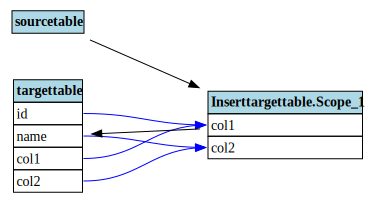

In [3]:
from lineage.parser.lineage_map import LineageMap
from lineage.serializers import to_graphviz

lm = LineageMap()

lm.parse_sql(sql8, "TEMP1")
to_graphviz(lm.table_node_map)

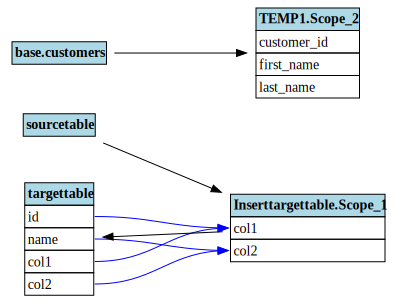

In [4]:
lm.parse_sql(sql4, "TEMP1")
to_graphviz(lm.table_node_map)

In [7]:
lm.table_node_map['targettable'].file_names

set()

In [ ]:
import logging
import sys
logging.basicConfig(
    stream=sys.stdout,
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s'
)

